# Simple Graph / TGraph / NetworkX Benchmark Harness

This notebook compares **Graph.py**, **TGraph.py**, and **NetworkX** for speed and basic correctness.

It assumes you already have two equivalent graph objects in memory:

```python
graph    # topologicpy.Graph graph
t_graph  # topologicpy.TGraph graph
```

The notebook first converts one of them to NetworkX and stores it as:

```python
nx_graph
```

It then compares:

1. Getting vertices / nodes
2. Getting edges
3. Computing shortest path
4. Overall graph metrics
5. Centrality measures

The benchmark produces numeric timing tables, correctness checks, winner summaries, visual runtime plots, and a concise text summary.


## 1. Imports and configuration


In [1]:
# This cell is not needed if you have pip installed topologicpy
import sys
sys.path.append("C:/Users/sarwj/OneDrive - Cardiff University/Documents/GitHub/topologicpy/src")

import math
import time
import statistics
import traceback
from dataclasses import dataclass
from typing import Any, Callable, Dict, List, Optional, Tuple

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    import networkx as nx
except Exception as exc:
    raise ImportError("NetworkX is required for this notebook. Install it with: pip install networkx") from exc

from topologicpy.Graph import Graph
from topologicpy.TGraph import TGraph
from topologicpy.Topology import Topology
from topologicpy.Vertex import Vertex
from topologicpy.Edge import Edge
from topologicpy.Dictionary import Dictionary
from topologicpy.Grid import Grid
from topologicpy.Face import Face

# Benchmark configuration.
REPEAT_FAST = 20
REPEAT_MEDIUM = 5
REPEAT_SLOW = 1
WARMUP = 1

# Shortest path endpoints. By default this uses the first and last vertex/node.
SOURCE_INDEX = 0
TARGET_INDEX = -1

# Edge weight key used by weighted/metric methods where available.
WEIGHT_KEY = "weight"

# Centrality tests can take a long time on large graphs.
RUN_BETWEENNESS = True
RUN_CLOSENESS = True

print("Imports complete.")


Imports complete.


In [2]:
def reset_dictionaries(shell):
    faces = Topology.Faces(shell)
    for i, f in enumerate(faces):
        d = Topology.Dictionary(f)
        keys = Dictionary.Keys(d)
        for key in keys:
            if not key == "face_id":
                d = Dictionary.RemoveKey(d, key)
        f = Topology.SetDictionary(f, d)

def transfer_dicts_by_key(topologies, selectors, key):
    dicts = {}
    for t in topologies:
        d = Topology.Dictionary(t)
        value = Dictionary.ValueAtKey(d, key, None)
        if value:
            dicts[str(value)] = t
    
    for s in selectors:
        d = Dictionary.ByPythonDictionary(s.get("dictionary", None))
        if d is not None:
            value = Dictionary.ValueAtKey(d, key, None)
            if value:
                f = dicts[str(value)]
                f = Topology.SetDictionary(f, d)

def distance_ranges_by_spacing(face, x_spacing=1.0, y_spacing=1.0, mantissa=6, tolerance=0.0001):
    """
    Converts x/y spacing distances into uRange/vRange distance lists
    suitable for Grid.EdgesByDistances.

    x_spacing controls spacing along the face's u direction.
    y_spacing controls spacing along the face's v direction.
    """

    def make_range(total_distance, spacing):
        spacing = float(spacing)

        if spacing <= tolerance:
            return [0.0, total_distance]

        values = [0.0]
        d = spacing

        while d < total_distance - tolerance:
            values.append(round(d, mantissa))
            d += spacing

        values.append(round(total_distance, mantissa))
        return values

    # Measure full physical distance along the face's u direction.
    u0 = Face.VertexByParameters(face, 0.0, 0.0)
    u1 = Face.VertexByParameters(face, 1.0, 0.0)
    u_total = Vertex.Distance(u0, u1)

    # Measure full physical distance along the face's v direction.
    v0 = Face.VertexByParameters(face, 0.0, 0.0)
    v1 = Face.VertexByParameters(face, 0.0, 1.0)
    v_total = Vertex.Distance(v0, v1)

    uRange = make_range(u_total, x_spacing)
    vRange = make_range(v_total, y_spacing)

    return uRange, vRange

gallery = Topology.ByBREPPath(r"C:\Users\sarwj\OneDrive - Cardiff University\IAAC\2025-26\S3 - Buildings As Graphs\notebooks\Supporting Files\gallery.brep")
from topologicpy.Grid import Grid

x_spacing = 2.0
y_spacing = 2.0

uRange, vRange = distance_ranges_by_spacing(
    gallery,
    x_spacing=x_spacing,
    y_spacing=y_spacing
)

grid = Grid.EdgesByDistances(
    face=gallery,
    uRange=uRange,
    vRange=vRange,
    clip=True
)

shell = Topology.Slice(gallery, grid)
faces = Topology.Faces(shell)
# Assign a sequential unique face id to reference it later (e.g. "face_21")
for i, f in enumerate(faces):
    d = Dictionary.ByKeyValue("face_id", "face_"+str(i+1))
    f = Topology.SetDictionary(f, d)

graph = Graph.ByTopology(shell)
t_graph = TGraph.ByTopology(shell)

## 2. Validate input objects

Run your own code before this cell to create:

```python
graph
t_graph
```


In [3]:
if "graph" not in globals():
    raise NameError("Expected a variable named 'graph' containing a topologicpy.Graph object.")

if "t_graph" not in globals():
    raise NameError("Expected a variable named 't_graph' containing a topologicpy.TGraph object.")

try:
    graph_order = Graph.Order(graph)
    graph_size = Graph.Size(graph)
except Exception as exc:
    raise TypeError("The variable 'graph' does not appear to be a valid topologicpy.Graph object.") from exc

try:
    tgraph_order = TGraph.Order(t_graph)
    tgraph_size = TGraph.Size(t_graph)
except Exception as exc:
    raise TypeError("The variable 't_graph' does not appear to be a valid topologicpy.TGraph object.") from exc

print("Graph.Order:", graph_order)
print("Graph.Size :", graph_size)
print("TGraph.Order:", tgraph_order)
print("TGraph.Size :", tgraph_size)

if graph_order != tgraph_order:
    print("WARNING: Graph and TGraph have different order values.")

if graph_size != tgraph_size:
    print("WARNING: Graph and TGraph have different size values.")


Graph.Order: 4624
Graph.Size : 8414
TGraph.Order: 4624
TGraph.Size : 8414


## 3. Convert to NetworkX

This conversion uses `t_graph` by default because TGraph records expose integer vertex indices directly. The resulting `nx_graph` uses the same integer node ids as TGraph.


In [4]:
def tgraph_to_networkx(tg):
    directed = bool(getattr(tg, "_directed", False))
    G = nx.DiGraph() if directed else nx.Graph()

    for v in getattr(tg, "_vertices", []):
        if not v.get("active", True):
            continue
        idx = v.get("index", None)
        if idx is None:
            continue
        d = v.get("dictionary", {})
        d = dict(d) if isinstance(d, dict) else {}
        G.add_node(idx, **d)

    for e in getattr(tg, "_edges", []):
        if not e.get("active", True):
            continue
        src = e.get("src", None)
        dst = e.get("dst", None)
        if src is None or dst is None:
            continue
        d = e.get("dictionary", {})
        d = dict(d) if isinstance(d, dict) else {}
        d.setdefault("index", e.get("index", None))
        d.setdefault("directed", e.get("directed", directed))

        if WEIGHT_KEY in d:
            try:
                d["weight"] = float(d[WEIGHT_KEY])
            except Exception:
                d["weight"] = 1.0
        elif "Length" in d:
            try:
                d["weight"] = float(d["Length"])
            except Exception:
                d["weight"] = 1.0
        else:
            d["weight"] = 1.0

        G.add_edge(src, dst, **d)

    return G

nx_graph = tgraph_to_networkx(t_graph)

print("NetworkX type :", type(nx_graph).__name__)
print("NetworkX nodes:", nx_graph.number_of_nodes())
print("NetworkX edges:", nx_graph.number_of_edges())


NetworkX type : Graph
NetworkX nodes: 4624
NetworkX edges: 8414


## 4. Benchmark helpers


In [5]:
@dataclass
class Result:
    category: str
    operation: str
    implementation: str
    ok: bool
    time_ms: Optional[float]
    value: Any
    summary: str
    error: str


def safe_call(func, *args, **kwargs):
    try:
        return True, func(*args, **kwargs), ""
    except Exception:
        return False, None, traceback.format_exc(limit=3)


def timed_call(func, *args, repeat=5, warmup=1, **kwargs):
    last_value = None
    for _ in range(max(0, warmup)):
        ok, last_value, err = safe_call(func, *args, **kwargs)
        if not ok:
            return False, None, None, err
    times = []
    for _ in range(max(1, repeat)):
        start = time.perf_counter()
        ok, last_value, err = safe_call(func, *args, **kwargs)
        elapsed = time.perf_counter() - start
        if not ok:
            return False, None, None, err
        times.append(elapsed * 1000.0)
    return True, last_value, statistics.median(times), ""


def simple_summary(value, max_len=160):
    if value is None:
        return "None"
    if isinstance(value, (int, float, str, bool)):
        return repr(value)
    if isinstance(value, (list, tuple, set)):
        seq = list(value)
        return f"{type(value).__name__}(len={len(seq)}, head={seq[:8]!r})"
    if isinstance(value, dict):
        keys = list(value.keys())
        return f"dict(len={len(value)}, keys={keys[:8]!r})"
    return repr(value)[:max_len]


def add_result(results, category, operation, implementation, func, *args, repeat=5, warmup=1, **kwargs):
    ok, value, time_ms, err = timed_call(func, *args, repeat=repeat, warmup=warmup, **kwargs)
    results.append(Result(category, operation, implementation, ok, time_ms, value, simple_summary(value), err))


def get_graph_vertices(g):
    return Graph.Vertices(g)


def get_tgraph_vertices(g):
    return TGraph.Vertices(g)


def get_nx_vertices(g):
    return list(g.nodes())


def get_graph_edges(g):
    return Graph.Edges(g)


def get_tgraph_edges(g):
    return TGraph.Edges(g)


def get_nx_edges(g):
    return list(g.edges())


def graph_vertex_by_index(g, index):
    vertices = Graph.Vertices(g)
    if index < 0:
        index = len(vertices) + index
    return vertices[index]


def tgraph_vertex_by_index(g, index):
    vertices = TGraph.Vertices(g)
    if index < 0:
        index = len(vertices) + index
    v = vertices[index]
    if isinstance(v, dict) and "index" in v:
        return v["index"]
    return index


def nx_vertex_by_index(g, index):
    nodes = list(g.nodes())
    if index < 0:
        index = len(nodes) + index
    return nodes[index]


def graph_shortest_path(g, source_index, target_index):
    s = graph_vertex_by_index(g, source_index)
    t = graph_vertex_by_index(g, target_index)
    return Graph.ShortestPath(g, s, t)


def tgraph_shortest_path(g, source_index, target_index):
    s = tgraph_vertex_by_index(g, source_index)
    t = tgraph_vertex_by_index(g, target_index)
    return TGraph.ShortestPath(g, s, t)


def nx_shortest_path(g, source_index, target_index):
    s = nx_vertex_by_index(g, source_index)
    t = nx_vertex_by_index(g, target_index)
    return nx.shortest_path(g, s, t)


def graph_metrics(g):
    return {
        "order": Graph.Order(g),
        "size": Graph.Size(g),
        "density": Graph.Density(g) if hasattr(Graph, "Density") else None,
        "degree_sequence": Graph.DegreeSequence(g) if hasattr(Graph, "DegreeSequence") else None,
    }


def tgraph_metrics(g):
    return {
        "order": TGraph.Order(g),
        "size": TGraph.Size(g),
        "density": TGraph.Density(g) if hasattr(TGraph, "Density") else None,
        "degree_sequence": TGraph.DegreeSequence(g) if hasattr(TGraph, "DegreeSequence") else None,
    }


def nx_metrics(g):
    return {
        "order": g.number_of_nodes(),
        "size": g.number_of_edges(),
        "density": nx.density(g),
        "degree_sequence": sorted([d for _, d in g.degree()], reverse=True),
    }


def graph_degree_centrality(g):
    return Graph.DegreeCentrality(g)


def tgraph_degree_centrality(g):
    return TGraph.DegreeCentrality(g)


def nx_degree_centrality(g):
    d = nx.degree_centrality(g)
    return [d[n] for n in sorted(d.keys())]


def graph_closeness_centrality(g):
    return Graph.ClosenessCentrality(g)


def tgraph_closeness_centrality(g):
    return TGraph.ClosenessCentrality(g)


def nx_closeness_centrality(g):
    d = nx.closeness_centrality(g)
    return [d[n] for n in sorted(d.keys())]


def graph_betweenness_centrality(g):
    return Graph.BetweennessCentrality(g)


def tgraph_betweenness_centrality(g):
    return TGraph.BetweennessCentrality(g)


def nx_betweenness_centrality(g):
    d = nx.betweenness_centrality(g, normalized=True)
    return [d[n] for n in sorted(d.keys())]


## 5. Run the benchmark


In [6]:
results = []

add_result(results, "Access", "Get vertices/nodes", "Graph", get_graph_vertices, graph, repeat=REPEAT_FAST, warmup=WARMUP)
add_result(results, "Access", "Get vertices/nodes", "TGraph", get_tgraph_vertices, t_graph, repeat=REPEAT_FAST, warmup=WARMUP)
add_result(results, "Access", "Get vertices/nodes", "NetworkX", get_nx_vertices, nx_graph, repeat=REPEAT_FAST, warmup=WARMUP)

add_result(results, "Access", "Get edges", "Graph", get_graph_edges, graph, repeat=REPEAT_FAST, warmup=WARMUP)
add_result(results, "Access", "Get edges", "TGraph", get_tgraph_edges, t_graph, repeat=REPEAT_FAST, warmup=WARMUP)
add_result(results, "Access", "Get edges", "NetworkX", get_nx_edges, nx_graph, repeat=REPEAT_FAST, warmup=WARMUP)

add_result(results, "Path", "Shortest path", "Graph", graph_shortest_path, graph, SOURCE_INDEX, TARGET_INDEX, repeat=REPEAT_MEDIUM, warmup=WARMUP)
add_result(results, "Path", "Shortest path", "TGraph", tgraph_shortest_path, t_graph, SOURCE_INDEX, TARGET_INDEX, repeat=REPEAT_MEDIUM, warmup=WARMUP)
add_result(results, "Path", "Shortest path", "NetworkX", nx_shortest_path, nx_graph, SOURCE_INDEX, TARGET_INDEX, repeat=REPEAT_MEDIUM, warmup=WARMUP)

add_result(results, "Metrics", "Overall graph metrics", "Graph", graph_metrics, graph, repeat=REPEAT_MEDIUM, warmup=WARMUP)
add_result(results, "Metrics", "Overall graph metrics", "TGraph", tgraph_metrics, t_graph, repeat=REPEAT_MEDIUM, warmup=WARMUP)
add_result(results, "Metrics", "Overall graph metrics", "NetworkX", nx_metrics, nx_graph, repeat=REPEAT_MEDIUM, warmup=WARMUP)

add_result(results, "Centrality", "Degree centrality", "Graph", graph_degree_centrality, graph, repeat=REPEAT_MEDIUM, warmup=WARMUP)
add_result(results, "Centrality", "Degree centrality", "TGraph", tgraph_degree_centrality, t_graph, repeat=REPEAT_MEDIUM, warmup=WARMUP)
add_result(results, "Centrality", "Degree centrality", "NetworkX", nx_degree_centrality, nx_graph, repeat=REPEAT_MEDIUM, warmup=WARMUP)

if RUN_CLOSENESS:
    add_result(results, "Centrality", "Closeness centrality", "Graph", graph_closeness_centrality, graph, repeat=REPEAT_SLOW, warmup=0)
    add_result(results, "Centrality", "Closeness centrality", "TGraph", tgraph_closeness_centrality, t_graph, repeat=REPEAT_SLOW, warmup=0)
    add_result(results, "Centrality", "Closeness centrality", "NetworkX", nx_closeness_centrality, nx_graph, repeat=REPEAT_SLOW, warmup=0)

if RUN_BETWEENNESS:
    add_result(results, "Centrality", "Betweenness centrality", "Graph", graph_betweenness_centrality, graph, repeat=REPEAT_SLOW, warmup=0)
    add_result(results, "Centrality", "Betweenness centrality", "TGraph", tgraph_betweenness_centrality, t_graph, repeat=REPEAT_SLOW, warmup=0)
    add_result(results, "Centrality", "Betweenness centrality", "NetworkX", nx_betweenness_centrality, nx_graph, repeat=REPEAT_SLOW, warmup=0)

df = pd.DataFrame([r.__dict__ for r in results])
df[["category", "operation", "implementation", "ok", "time_ms", "summary"]]


,category,operation,implementation,ok,time_ms,summary
0,Access,Get vertices/nodes,Graph,True,271.30180,"list(len=4624, head=[<topologic_core.Vertex ob..."
1,Access,Get vertices/nodes,TGraph,True,1.36655,"list(len=4624, head=[{'index': 0, 'dictionary'..."
2,Access,Get vertices/nodes,NetworkX,True,0.01715,"list(len=4624, head=[0, 1, 2, 3, 4, 5, 6, 7])"
3,Access,Get edges,Graph,True,10250.17715,"list(len=8414, head=[<topologic_core.Edge obje..."
4,Access,Get edges,TGraph,True,3.09760,"list(len=8414, head=[{'index': 0, 'src': 0, 'd..."
5,Access,Get edges,NetworkX,True,1.45430,"list(len=8414, head=[(0, 3), (0, 2), (0, 1), (..."
6,Path,Shortest path,Graph,True,1627.40800,<topologic_core.Wire object at 0x000002AB702A4...
7,Path,Shortest path,TGraph,True,3.21140,"list(len=128, head=[0, 1, 4, 9, 17, 28, 41, 53])"
8,Path,Shortest path,NetworkX,True,1.08220,"list(len=128, head=[0, 2, 6, 12, 20, 31, 44, 56])"
9,Metrics,Overall graph metrics,Graph,True,21293.89890,"dict(len=4, keys=['order', 'size', 'density', ..."


## 6. Correctness checks

These checks focus on simple, comparable facts. Centrality definitions can differ between implementations, so the notebook flags approximate agreement rather than assuming exact equality.


In [8]:
def approx_equal(a, b, rel_tol=1e-5, abs_tol=1e-5):
    try:
        return math.isclose(float(a), float(b), rel_tol=rel_tol, abs_tol=abs_tol)
    except Exception:
        return a == b


def list_approx_equal(a, b, rel_tol=1e-4, abs_tol=1e-4):
    try:
        a = list(a)
        b = list(b)
        if len(a) != len(b):
            return False
        return all(approx_equal(x, y, rel_tol=rel_tol, abs_tol=abs_tol) for x, y in zip(a, b))
    except Exception:
        return False


def get_value(operation, implementation):
    subset = df[(df["operation"] == operation) & (df["implementation"] == implementation)]
    if len(subset) == 0:
        return None, False
    row = subset.iloc[0]
    return row["value"], bool(row["ok"])

checks = []

g_v, g_ok = get_value("Get vertices/nodes", "Graph")
tg_v, tg_ok = get_value("Get vertices/nodes", "TGraph")
nx_v, nx_ok = get_value("Get vertices/nodes", "NetworkX")
checks.append({
    "check": "vertex/node count",
    "Graph vs TGraph": g_ok and tg_ok and len(g_v) == len(tg_v),
    "Graph vs NetworkX": g_ok and nx_ok and len(g_v) == len(nx_v),
    "TGraph vs NetworkX": tg_ok and nx_ok and len(tg_v) == len(nx_v),
    "details": f"Graph={len(g_v) if g_ok else None}, TGraph={len(tg_v) if tg_ok else None}, NetworkX={len(nx_v) if nx_ok else None}",
})

g_e, g_ok = get_value("Get edges", "Graph")
tg_e, tg_ok = get_value("Get edges", "TGraph")
nx_e, nx_ok = get_value("Get edges", "NetworkX")
checks.append({
    "check": "edge count",
    "Graph vs TGraph": g_ok and tg_ok and len(g_e) == len(tg_e),
    "Graph vs NetworkX": g_ok and nx_ok and len(g_e) == len(nx_e),
    "TGraph vs NetworkX": tg_ok and nx_ok and len(tg_e) == len(nx_e),
    "details": f"Graph={len(g_e) if g_ok else None}, TGraph={len(tg_e) if tg_ok else None}, NetworkX={len(nx_e) if nx_ok else None}",
})

g_p, g_ok = get_value("Shortest path", "Graph")
g_p = Topology.Vertices(g_p)
tg_p, tg_ok = get_value("Shortest path", "TGraph")
nx_p, nx_ok = get_value("Shortest path", "NetworkX")
checks.append({
    "check": "shortest path length",
    "Graph vs TGraph": g_ok and tg_ok and len(g_p) == len(tg_p),
    "Graph vs NetworkX": g_ok and nx_ok and len(g_p) == len(nx_p),
    "TGraph vs NetworkX": tg_ok and nx_ok and len(tg_p) == len(nx_p),
    "details": f"Graph={len(g_p) if g_ok else None}, TGraph={len(tg_p) if tg_ok else None}, NetworkX={len(nx_p) if nx_ok else None}",
})

g_m, g_ok = get_value("Overall graph metrics", "Graph")
tg_m, tg_ok = get_value("Overall graph metrics", "TGraph")
nx_m, nx_ok = get_value("Overall graph metrics", "NetworkX")

def metrics_match(a, b):
    if not isinstance(a, dict) or not isinstance(b, dict):
        return False
    if a.get("order") != b.get("order"):
        return False
    if a.get("size") != b.get("size"):
        return False
    if a.get("density") is not None and b.get("density") is not None:
        if not approx_equal(a.get("density"), b.get("density")):
            return False
    return True

checks.append({
    "check": "overall graph metrics",
    "Graph vs TGraph": g_ok and tg_ok and metrics_match(g_m, tg_m),
    "Graph vs NetworkX": g_ok and nx_ok and metrics_match(g_m, nx_m),
    "TGraph vs NetworkX": tg_ok and nx_ok and metrics_match(tg_m, nx_m),
    "details": f"Graph={g_m if g_ok else None}, TGraph={tg_m if tg_ok else None}, NetworkX={nx_m if nx_ok else None}",
})

for centrality_name in ["Degree centrality", "Closeness centrality", "Betweenness centrality"]:
    g_c, g_ok = get_value(centrality_name, "Graph")
    tg_c, tg_ok = get_value(centrality_name, "TGraph")
    nx_c, nx_ok = get_value(centrality_name, "NetworkX")
    if g_c is None and tg_c is None and nx_c is None:
        continue
    checks.append({
        "check": centrality_name.lower(),
        "Graph vs TGraph": g_ok and tg_ok and list_approx_equal(g_c, tg_c),
        "Graph vs NetworkX": g_ok and nx_ok and list_approx_equal(g_c, nx_c),
        "TGraph vs NetworkX": tg_ok and nx_ok and list_approx_equal(tg_c, nx_c),
        "details": f"lengths: Graph={len(g_c) if g_ok else None}, TGraph={len(tg_c) if tg_ok else None}, NetworkX={len(nx_c) if nx_ok else None}",
    })

correctness_df = pd.DataFrame(checks)
correctness_df


,check,Graph vs TGraph,Graph vs NetworkX,TGraph vs NetworkX,details
0,vertex/node count,True,True,True,"Graph=4624, TGraph=4624, NetworkX=4624"
1,edge count,True,True,True,"Graph=8414, TGraph=8414, NetworkX=8414"
2,shortest path length,True,True,True,"Graph=128, TGraph=128, NetworkX=128"
3,overall graph metrics,True,True,True,"Graph={'order': 4624, 'size': 8414, 'density':..."
4,degree centrality,True,True,True,"lengths: Graph=4624, TGraph=4624, NetworkX=4624"
5,closeness centrality,True,True,True,"lengths: Graph=4624, TGraph=4624, NetworkX=4624"
6,betweenness centrality,True,True,True,"lengths: Graph=4624, TGraph=4624, NetworkX=4624"


## 7. Speed winners


In [9]:
speed_df = df[df["ok"] == True].copy()
speed_df["time_ms"] = speed_df["time_ms"].astype(float)

winner_rows = []
for operation, group in speed_df.groupby("operation"):
    group = group.sort_values("time_ms")
    winner = group.iloc[0]
    row = {
        "operation": operation,
        "winner": winner["implementation"],
        "winning_time_ms": winner["time_ms"],
    }
    for _, item in group.iterrows():
        row[f"{item['implementation']}_ms"] = item["time_ms"]
    for _, item in group.iterrows():
        row[f"{item['implementation']}_slowdown_vs_winner"] = item["time_ms"] / winner["time_ms"] if winner["time_ms"] > 0 else None
    winner_rows.append(row)

winners_df = pd.DataFrame(winner_rows).sort_values("operation")
winners_df


,operation,winner,winning_time_ms,TGraph_ms,NetworkX_ms,Graph_ms,TGraph_slowdown_vs_winner,NetworkX_slowdown_vs_winner,Graph_slowdown_vs_winner
0,Betweenness centrality,TGraph,33533.06190,33533.06190,36171.49090,50427.44000,1.000000,1.078681,1.503813
1,Closeness centrality,TGraph,4940.48720,4940.48720,5130.33940,21386.21990,1.000000,1.038428,4.328767
2,Degree centrality,NetworkX,0.65360,472.81770,0.65360,200122.83440,723.405326,1.000000,306185.500746
3,Get edges,NetworkX,1.45430,3.09760,1.45430,10250.17715,2.129959,1.000000,7048.186244
4,Get vertices/nodes,NetworkX,0.01715,1.36655,0.01715,271.30180,79.682420,1.000000,15819.387557
5,Overall graph metrics,TGraph,1.07620,1.07620,1.36090,21293.89890,1.000000,1.264542,19786.190296
6,Shortest path,NetworkX,1.08220,3.21140,1.08220,1627.40800,2.967474,1.000000,1503.796006


## 8. Visual runtime report


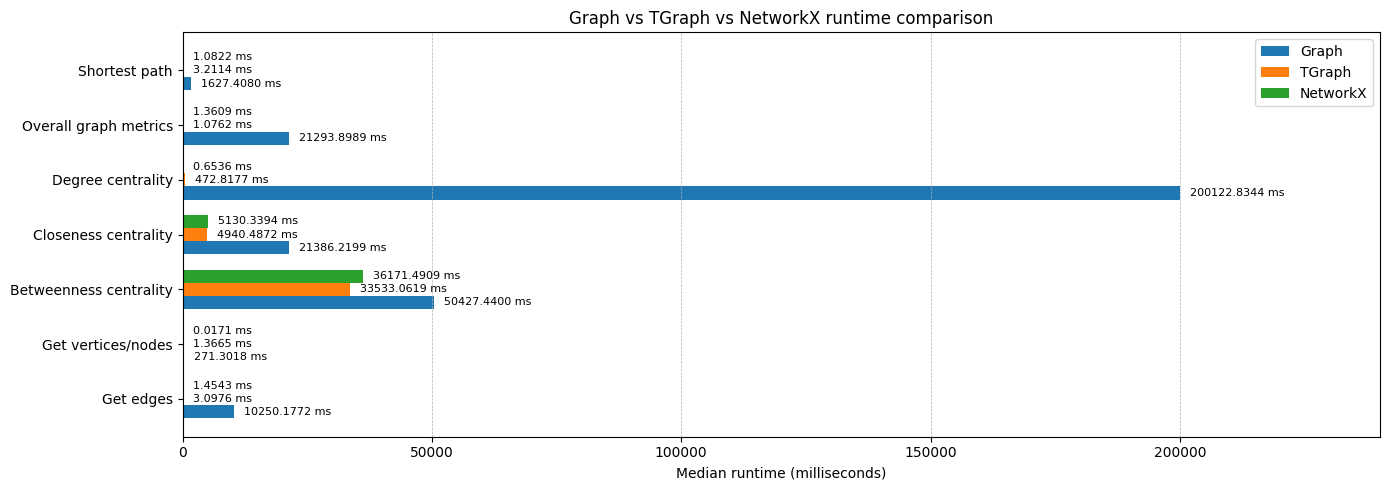

In [10]:
plot_df = speed_df.copy().sort_values(["category", "operation", "time_ms"])
operations = list(plot_df["operation"].unique())
implementations = ["Graph", "TGraph", "NetworkX"]

fig, ax = plt.subplots(figsize=(14, max(5, len(operations) * 0.7)))
y = np.arange(len(operations))
height = 0.24
offsets = {"Graph": -height, "TGraph": 0.0, "NetworkX": height}

max_time = plot_df["time_ms"].max()
label_offset = max_time * 0.01 if max_time > 0 else 0.001

for impl in implementations:
    times = []
    for op in operations:
        row = plot_df[(plot_df["operation"] == op) & (plot_df["implementation"] == impl)]
        times.append(float(row.iloc[0]["time_ms"]) if len(row) else np.nan)
    positions = y + offsets[impl]
    ax.barh(positions, times, height=height, label=impl)
    for yy, t in zip(positions, times):
        if not np.isnan(t):
            ax.text(t + label_offset, yy, f"{t:.4f} ms", va="center", ha="left", fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(operations)
ax.set_xlabel("Median runtime (milliseconds)")
ax.set_title("Graph vs TGraph vs NetworkX runtime comparison")
ax.set_xlim(0, max_time * 1.20 if max_time > 0 else 1)
ax.grid(True, axis="x", linestyle="--", linewidth=0.5)
ax.legend()
fig.tight_layout()
plt.show()


## 9. Winner count chart


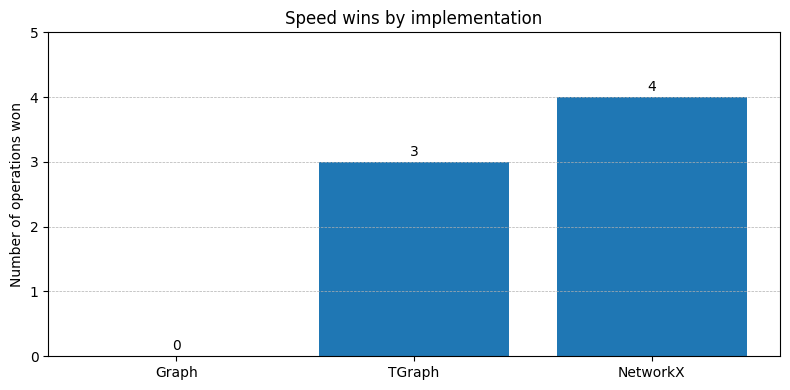

In [11]:
winner_count = winners_df["winner"].value_counts().reindex(["Graph", "TGraph", "NetworkX"], fill_value=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(winner_count.index, winner_count.values)
ax.set_ylabel("Number of operations won")
ax.set_title("Speed wins by implementation")
for i, value in enumerate(winner_count.values):
    ax.text(i, value + 0.05, str(int(value)), ha="center", va="bottom")
ax.set_ylim(0, max(winner_count.values) + 1 if max(winner_count.values) > 0 else 1)
ax.grid(True, axis="y", linestyle="--", linewidth=0.5)
fig.tight_layout()
plt.show()


## 10. Text summary


In [12]:
print("Benchmark summary")
print("=================")
print()
print("Graph size")
print(f"- Graph    : order={graph_order}, size={graph_size}")
print(f"- TGraph   : order={tgraph_order}, size={tgraph_size}")
print(f"- NetworkX : order={nx_graph.number_of_nodes()}, size={nx_graph.number_of_edges()}")
print()
print("Speed winners")
print("-------------")
for _, row in winners_df.iterrows():
    print(f"- {row['operation']}: {row['winner']} ({row['winning_time_ms']:.4f} ms)")
print()
print("Winner counts")
print("-------------")
for impl, count in winner_count.items():
    print(f"- {impl}: {int(count)}")
print()
print("Correctness checks")
print("------------------")
for _, row in correctness_df.iterrows():
    status = "PASS" if bool(row["Graph vs TGraph"]) and bool(row["Graph vs NetworkX"]) and bool(row["TGraph vs NetworkX"]) else "CHECK"
    print(f"- {row['check']}: {status}")
    print(f"  {row['details']}")


Benchmark summary

Graph size
- Graph    : order=4624, size=8414
- TGraph   : order=4624, size=8414
- NetworkX : order=4624, size=8414

Speed winners
-------------
- Betweenness centrality: TGraph (33533.0619 ms)
- Closeness centrality: TGraph (4940.4872 ms)
- Degree centrality: NetworkX (0.6536 ms)
- Get edges: NetworkX (1.4543 ms)
- Get vertices/nodes: NetworkX (0.0171 ms)
- Overall graph metrics: TGraph (1.0762 ms)
- Shortest path: NetworkX (1.0822 ms)

Winner counts
-------------
- Graph: 0
- TGraph: 3
- NetworkX: 4

Correctness checks
------------------
- vertex/node count: PASS
  Graph=4624, TGraph=4624, NetworkX=4624
- edge count: PASS
  Graph=8414, TGraph=8414, NetworkX=8414
- shortest path length: PASS
  Graph=128, TGraph=128, NetworkX=128
- overall graph metrics: PASS
  Graph={'order': 4624, 'size': 8414, 'density': 0.0007872103301755103, 'degree_sequence': [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4,

## 11. Export reports


In [ ]:
from datetime import datetime
from pathlib import Path

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
timing_path = Path(f"graph_tgraph_networkx_timing_{timestamp}.csv").resolve()
correctness_path = Path(f"graph_tgraph_networkx_correctness_{timestamp}.csv").resolve()
winners_path = Path(f"graph_tgraph_networkx_winners_{timestamp}.csv").resolve()

df.drop(columns=["value"]).to_csv(timing_path, index=False)
correctness_df.to_csv(correctness_path, index=False)
winners_df.to_csv(winners_path, index=False)

print("Saved timing report     :", timing_path)
print("Saved correctness report:", correctness_path)
print("Saved winners report    :", winners_path)
